# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Koh Tim Yi



In [ ]:
Student Name: Koh Tim Yi
Metric Number: 2503677C

**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [2]:
## Import libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# 1. Business Understanding
Goal: HDB resale flat prices in Singapore vary widely depending on location, flat type, size, and lease remaining, which makes it difficult for buyers, sellers, and agents to judge whether an asking price is fair. The goal of this model is  to build a machine learning model that predicts the resale price of an HDB flat based on its characteristics such as town, flat type, floor area, storey range, flat model, lease commencement date, and remaining lease.A reliable pricing estimate tool would help sellers set realistic asking prices, help buyers identify over or underpriced listings, and help agents justify valuations to their clients, ultimately reducing time doing reserch and negotiation friction.


# 2. Data Understanding

## 2.1 Load dataset

In [3]:
## Read *.csv file into pandas DataFrame
df = pd.read_csv("ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv")
print(df.shape)
df.head()


(236609, 11)


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


## 2.2 Summary Statistics

In [4]:
## Understand the type of variable for each column
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236609 entries, 0 to 236608
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                236609 non-null  object 
 1   town                 236609 non-null  object 
 2   flat_type            236609 non-null  object 
 3   block                236609 non-null  object 
 4   street_name          236609 non-null  object 
 5   storey_range         236609 non-null  object 
 6   floor_area_sqm       236609 non-null  float64
 7   flat_model           236609 non-null  object 
 8   lease_commence_date  236609 non-null  int64  
 9   remaining_lease      236609 non-null  object 
 10  resale_price         236609 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 19.9+ MB


df.info() prints out the summary of the DataFrame's structure such as the total row count and for each column its name,how many non-null value it has and its data type. After running, we see that there are no missing data anywhere. It also showed remaining_lease as object while floor_area_sqm and resale_price are float64  and lease_commence_date is int64 . This matters because scikit-learn models can't consume text directly and any object column either needs to be encoded into numbers (like town, flat_type, flat_model via one-hot encoding) or parsed into a numeric value (like remaining_lease, which is a string such as "61 years 04 months" that needs to become a number,eg. total months or years, before a model can use it).

In [5]:
## Check for missing data
df.isnull().sum()


month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
dtype: int64

df.isnull().sum() is a standard command used to check whether any data is missing from your dataset. Firstly,df.isnull() scans every cell in your table and if a cell has data, it gets labeled as False, and if a cell is empty, it gets labeled as True. Then, .sum() adds those numbers up for each column, giving you a final count of missing values. Even though df.info() already showed that every single row has complete data—meaning this check will simply output zeros for every column. This just helps to verify that there are 0 missing data from the dataset.

In [6]:
## Describe data distribution
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
month,236609,115,2024-07,3036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
town,236609,26,SENGKANG,19183,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flat_type,236609,7,4 ROOM,100489,NaN,NaN,NaN,NaN,NaN,NaN,NaN
block,236609,2773,2,712,NaN,NaN,NaN,NaN,NaN,NaN,NaN
street_name,236609,578,YISHUN RING RD,3343,NaN,NaN,NaN,NaN,NaN,NaN,NaN
storey_range,236609,17,04 TO 06,54249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
floor_area_sqm,236609.0,NaN,NaN,NaN,96.685218,24.017699,31.0,81.0,93.0,112.0,366.7
flat_model,236609,21,Model A,85174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lease_commence_date,236609.0,NaN,NaN,NaN,1996.58095,14.373906,1966.0,1985.0,1997.0,2012.0,2022.0
remaining_lease,236609,701,94 years 10 months,1928,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Running `df.describe(include="all").T` generates a comprehensive summary of your entire dataset by combining math statistics for numerical columns with categorical metrics for text columns, and then transposing the resulting table for easy reading. Normally, `df.describe()` only analyzes numeric features like `resale_price` and `floor_area_sqm` by calculating their range, average, and spread, which helps you quickly spot outliers or potential data errors like zero floor areas or unrealistic prices. Adding `include="all"` forces pandas to also analyze text columns like `town` or `flat_model`, displaying their category counts (`unique`), most frequent value (`top`), and occurrence frequency (`freq`) so you know how many new columns One-Hot Encoding will eventually create. Finally, chaining `.T` at the end flips the output's rows and columns sideways, displaying all 11 features vertically down the page so you can inspect the full data health check without scrolling horizontally.

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

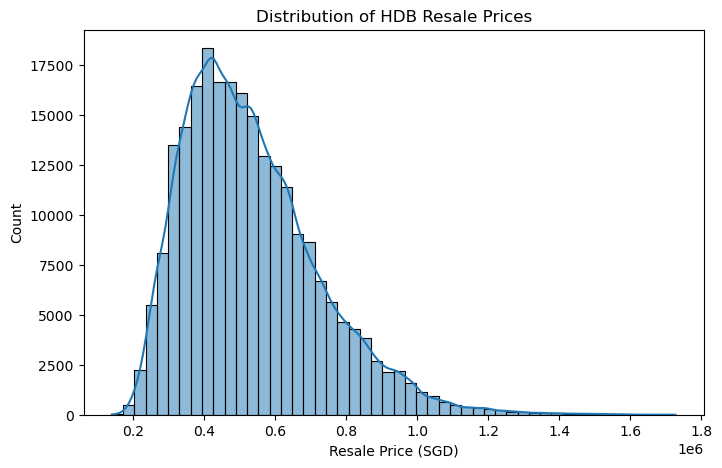

In [12]:
## Understanding distribution of target
plt.figure(figsize=(8, 5))
sns.histplot(df["resale_price"], bins=50, kde=True)
plt.title("Distribution of HDB Resale Prices")
plt.xlabel("Resale Price (SGD)")
plt.ylabel("Count")
plt.show()


Analysis of the target variable (resale_price) reveals a distinct right-skewed distribution across the dataset. Transaction values predominantly cluster within the $300,000–$650,000 range, exhibiting a clear mode between $400,000 and $450,000. A prolonged positive tail extends upward to maximum transaction values of $1.7 million.

### 2.3.1.2 Understanding distribution of features

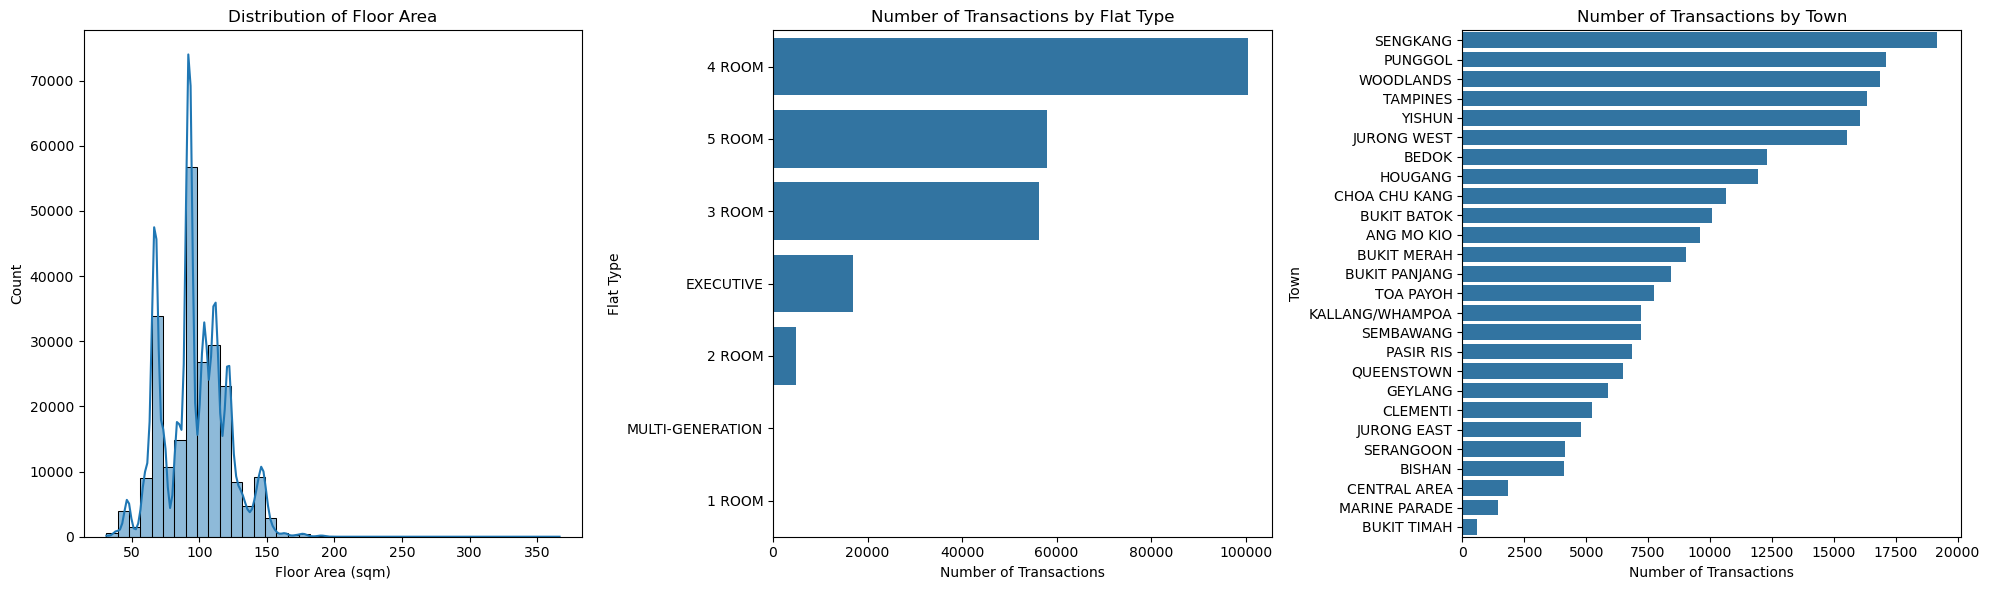

In [13]:
## Understanding distribution of features
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Numeric feature: floor area
sns.histplot(df["floor_area_sqm"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Floor Area")
axes[0].set_xlabel("Floor Area (sqm)")
axes[0].set_ylabel("Count")

# Categorical feature: flat type
sns.countplot(y=df["flat_type"], order=df["flat_type"].value_counts().index, ax=axes[1])
axes[1].set_title("Number of Transactions by Flat Type")
axes[1].set_xlabel("Number of Transactions")
axes[1].set_ylabel("Flat Type")

# Categorical feature: town
sns.countplot(y=df["town"], order=df["town"].value_counts().index, ax=axes[2])
axes[2].set_title("Number of Transactions by Town")
axes[2].set_xlabel("Number of Transactions")
axes[2].set_ylabel("Town")

plt.tight_layout()
plt.show()


-My Analysis-


Floor Area (floor_area_sqm): Exhibits sharp multi-modal spikes at standard HDB dimensions (67, 92, and 93 sqm) rather than a smooth distribution, introducing significant potential multicollinearity with flat_type.

Flat Type (flat_type): Highly imbalanced toward mainstream units (4-room flats comprise 42% of 236,609 total transactions), meaning models will perform reliably on mainstream types but require uncertainty disclaimers for rare types (<100 transactions, e.g., 1-room and multi-generation).

Town (town): Distributed across all 26 towns with sufficient volume even in low-density mature estates (minimum 576 transactions in Bukit Timah), making it safe for direct one-hot encoding without prior regional grouping.

### 2.3.2 Understanding relationship between variables

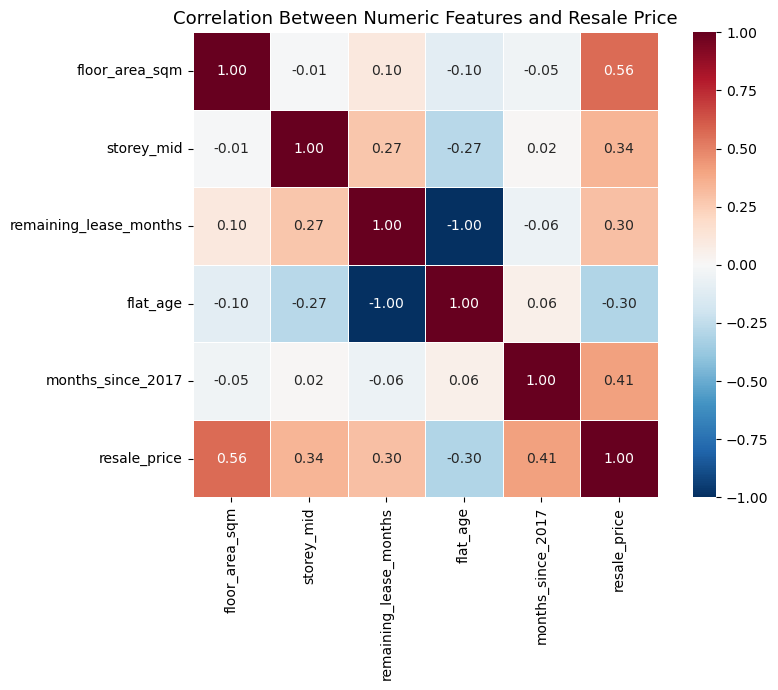

Correlation with resale_price, ranked:
floor_area_sqm            0.564377
months_since_2017         0.411395
storey_mid                0.341788
remaining_lease_months    0.301295
flat_age                 -0.300014
Name: resale_price, dtype: float64


In [15]:
## Understanding relationship between variables


eda = df.copy()

# "61 years 04 months" -> 736 months
_lease = eda["remaining_lease"].str.extract(r"^(\d+)\s+years?(?:\s+(\d+)\s+months?)?$")
eda["remaining_lease_months"] = _lease[0].astype(int) * 12 + _lease[1].fillna(0).astype(int)

# "10 TO 12" -> 11.0, the midpoint of the storey band
_storey = eda["storey_range"].str.extract(r"^(\d+)\s+TO\s+(\d+)$")
eda["storey_mid"] = (_storey[0].astype(int) + _storey[1].astype(int)) / 2

# "2017-01" -> 0, "2017-02" -> 1, ... how far into the market history the sale happened
_period = pd.PeriodIndex(eda["month"], freq="M")
eda["months_since_2017"] = (_period.year - 2017) * 12 + (_period.month - 1)

# Age of the flat at the point of sale
eda["flat_age"] = _period.year - eda["lease_commence_date"]

numeric_cols = ["floor_area_sqm", "storey_mid", "remaining_lease_months",
                "flat_age", "months_since_2017", "resale_price"]

plt.figure(figsize=(9, 7))
sns.heatmap(eda[numeric_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Correlation Between Numeric Features and Resale Price", fontsize=13)
plt.tight_layout()
plt.show()

print("Correlation with resale_price, ranked:")
print(eda[numeric_cols].corr()["resale_price"].drop("resale_price").sort_values(ascending=False))


-My Analysis_

Looking at the correlation matrix, floor area (floor_area_sqm) is the biggest numeric factor for price at $+0.56$, which makes sense because bigger flats cost more, but since it’s only a moderate correlation, stuff like location (town) is obviously doing a lot of the heavy lifting behind the scenes. Transaction date (months_since_2017 at $+0.41$) is the second biggest driver, showing how prices shot up between 2017 and 2026, so we definitely need time-based features to get accurate current valuations instead of treating an old sale like a recent one. Higher floors also get a price bump (storey_mid at $+0.34$), which makes converting the storey ranges into numeric midpoints worth it. Lastly, flat age and remaining lease are basically exact opposites ($-0.30$ and $+0.30$) because of HDB's 99-year lease rule, so keeping both would just cause bad multicollinearity—meaning we should just drop one before training the models.


# 3. Data Preparation

## 3.1 Data Cleaning

In [ ]:
## Clean data

## 3.2 Train-Test Split

In [ ]:
## Split data into train set and test set


# 4. Modelling

### 4.2 Train Model

In [ ]:
## Initialise and train model


# 5. Model Evaluation

In [ ]:
## Evaluate model


In [ ]:
## New data

## Predict


## Iterative model development


In [ ]:
## Further feature engineering / feature selection